# building basic chat bot using langgrpah(graph api)

In [93]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [92]:
class State(TypedDict):
    # messages have the type list. the add_messages function 
    # in the annotaation defines how this state key should be updated 
    # in this case it appends messages to the list, rather than overwriting them
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)


In [73]:
# graph_builder

In [74]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [75]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model = "llama-3.1-8b-instant")       # using model from playground
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000024558DC0950>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000024559E40CE0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [76]:
llm=init_chat_model('groq:llama-3.1-8b-instant')     # bith ways are fine

In [77]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [78]:
graph_builder=StateGraph(State)

# adding nodes
graph_builder.add_node("llmchat", chatbot)
## addung edges
graph_builder.add_edge(START, "llmchat")
graph_builder.add_edge("llmchat", END)       # going to end note

# compile the graph
graph=graph_builder.compile()
# run the graph


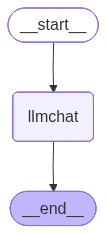

In [79]:
# visualize the graph
from IPython.display import Image,  display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
    pass

In [80]:
response=graph.invoke({"messages":["Hi"]})

In [81]:
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='792b15ae-b688-4537-b380-e9b63af05e5a'),
  AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.006583523, 'completion_tokens_details': None, 'prompt_time': 0.002562258, 'prompt_tokens_details': None, 'queue_time': 0.15881033, 'total_time': 0.009145781}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db84a-b49b-75e3-82c0-9b27d06d14b8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})]}

In [82]:
# Annotations are a powerful way to specify how the state should be updated. 
# In this example, we use the add_messages annotation to specify that when we update the messages key in the state,
# we want to append new messages to the existing list of messages rather than overwriting it. 
# This allows us to maintain a conversation history in our chatbot application.

In [83]:
response['messages'][-1].content

'How can I assist you today?'

In [84]:
for event in graph.stream({"messages": ["HI how are you?"]}):
    print(event)


{'llmchat': {'messages': [AIMessage(content="I'm just a computer program, so I don't have feelings or emotions like humans do, but thank you for asking. I'm functioning properly and ready to help with any questions or tasks you have. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 40, 'total_tokens': 89, 'completion_time': 0.438655918, 'completion_tokens_details': None, 'prompt_time': 0.003718019, 'prompt_tokens_details': None, 'queue_time': 0.111149539, 'total_time': 0.442373937}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db84a-b634-7901-8d19-474bf8e3d86d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 49, 'total_tokens': 89})]}}


In [85]:
for event in graph.stream({"messages": ["HI how are you?"]}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a computer program, so I don't have emotions or feelings like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How can I assist you today?


# Chatbot with tools

In [86]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")


{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
   'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?',
   'content': 'LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. By managing the flow of data and the sequence of operations, LangGraph allows developers to focus on the high-level logic of their applications rather than the intricacies of agent coordination. Whether you need a chatbot that can handle various types of user requests or a multi-agent system that performs complex tasks, LangGraph provides the tools to build exactly what you need. LangGraph allows you to create custom node types to implement complex agent logic. LangGraph significantly simplifies the development of complex LLM applications by pro

In [110]:
# custome function/method
## Custom function
def multiply(a: int, b: int) -> int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: _description_output_int
    """
    return a*b

In [111]:
tools=[tool,multiply]

In [112]:
llm_with_tool=llm.bind_tools(tools)

In [113]:
llm_with_tool

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000024559E41DC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000024559E42720>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers 

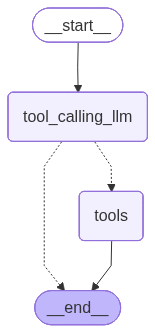

In [ ]:
# Creating a state graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node Defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# adding edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                              # if the latest message in the messages list contains a tool call, then go to the tools node
                              # if the latest message in the messages list does not contain a tool call, then go to the end node
                               tools_condition)
builder.add_edge("tools",END)      

## compileing the graph

graph=builder.compile()
from IPython.display import Image,  display
display(Image(graph.get_graph().draw_mermaid_png()))

In [115]:
graph.invoke({"messages":"What is recent ai news?"}) #here ai message is emty but it made tool call

{'messages': [HumanMessage(content='What is recent ai news?', additional_kwargs={}, response_metadata={}, id='be0a1ce4-2f6a-4248-a6ba-bd2709c9f4eb'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'sm2ms6xye', 'function': {'arguments': '{"query":"recent ai news","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 1751, 'total_tokens': 1775, 'completion_time': 0.069126043, 'completion_tokens_details': None, 'prompt_time': 0.141737778, 'prompt_tokens_details': None, 'queue_time': 0.109872518, 'total_time': 0.210863821}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db89f-5b3d-7502-9607-fac27b1b919a-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent ai news', 'topic': 'news'}, 'id': 'sm2ms6xye', 'type': 'tool_call'}

In [116]:
# saving in 
response=graph.invoke({"messages":"What is recent ai news?"})

In [117]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/04/22/ai-tech-brief-beijing-tightens-grip-ai-startups/", "title": "AI & Tech Brief: Beijing tightens grip on AI startups - The Washington Post", "score": 0.6493346, "published_date": "Wed, 22 Apr 2026 21:02:41 GMT", "content": "AI & Tech Brief from WP Intelligence. # AI & Tech Brief: Beijing tightens grip on AI startups. Plus, a coalition emerges around Sen. Marsha Blackburn’s AI framework. Make us preferred on Google. Sign up here to get this newsletter in your inbox. * Chinese authorities are moving to block domestic AI start-ups and talent from leaving the country in pursuit of Western capital. * **Breaking:** Sen. Marsha Blackburn (R-Tennessee) touts new support from think tanks and industry groups. * Florida Attorney General James Uthmeier opens a criminal investigation into OpenAI, alleging that a man used C

In [118]:
# for better way 
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (4ck3n4cyc)
 Call ID: 4ck3n4cyc
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/04/22/ai-tech-brief-beijing-tightens-grip-ai-startups/", "title": "AI & Tech Brief: Beijing tightens grip on AI startups - The Washington Post", "score": 0.6493346, "published_date": "Wed, 22 Apr 2026 21:02:41 GMT", "content": "AI & Tech Brief from WP Intelligence. # AI & Tech Brief: Beijing tightens grip on AI startups. Plus, a coalition emerges around Sen. Marsha Blackburn’s AI framework. Make us prefe

In [119]:
response=graph.invoke({"messages":"What is 2 multiplied by 3"})
for m in response['messages']:
    m.pretty_print()
# here there is multiply toolcall and the result is shown in the messages list. 
# this shows how we can use tools in our graph and how the state is updated with the results of the tool calls.

# but not producing output for some reason.  because return a*b was not defined in the multiply function.  we need to return the result of the multiplication in the multiply function for it to be shown in the messages list.

================================ Human Message =================================

What is 2 multiplied by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (az5sx8pvd)
 Call ID: az5sx8pvd
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [122]:
response=graph.invoke({"messages":"What is 2 multiplied by 3 and then multiplied by 4?"}) # check message
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 3 and then multiplied by 4?
================================== Ai Message ==================================
Tool Calls:
  multiply (p64fsqx8x)
 Call ID: p64fsqx8x
  Args:
    a: 6
    b: 4
================================= Tool Message =================================
Name: multiply

24


In [ ]:
response=graph.invoke({"messages":"give me the recent ai news and then multiply 2 and 3"}) # check message
for m in response['messages']:
    m.pretty_print()



================================ Human Message =================================

give me the recent ai news and then multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (9dfzcm82g)
 Call ID: 9dfzcm82g
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (ezw7e006g)
 Call ID: ezw7e006g
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/04/22/ai-tech-brief-beijing-tightens-grip-ai-startups/", "title": "AI & Tech Brief: Beijing tightens grip on AI startups - The Washington Post", "score": 0.6654328, "published_date": "Wed, 22 Apr 2026 21:02:41 GMT", "content": "AI & Tech Brief from WP Intelligence. # AI & Tech Brief: Beijing tightens grip on

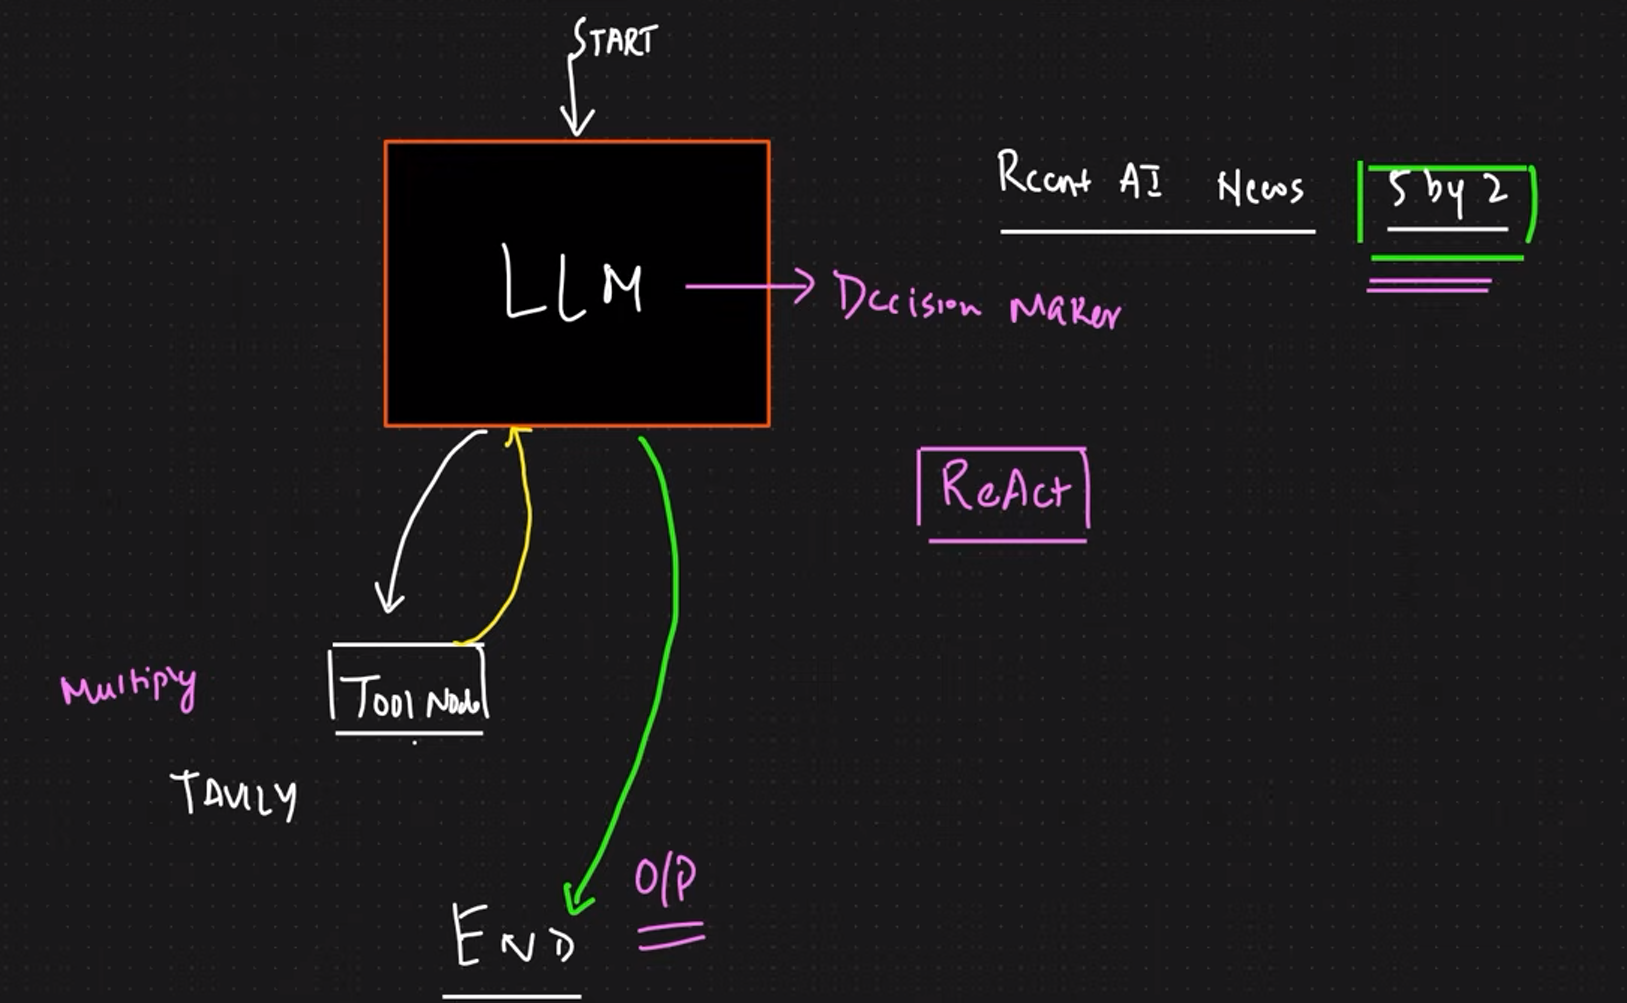

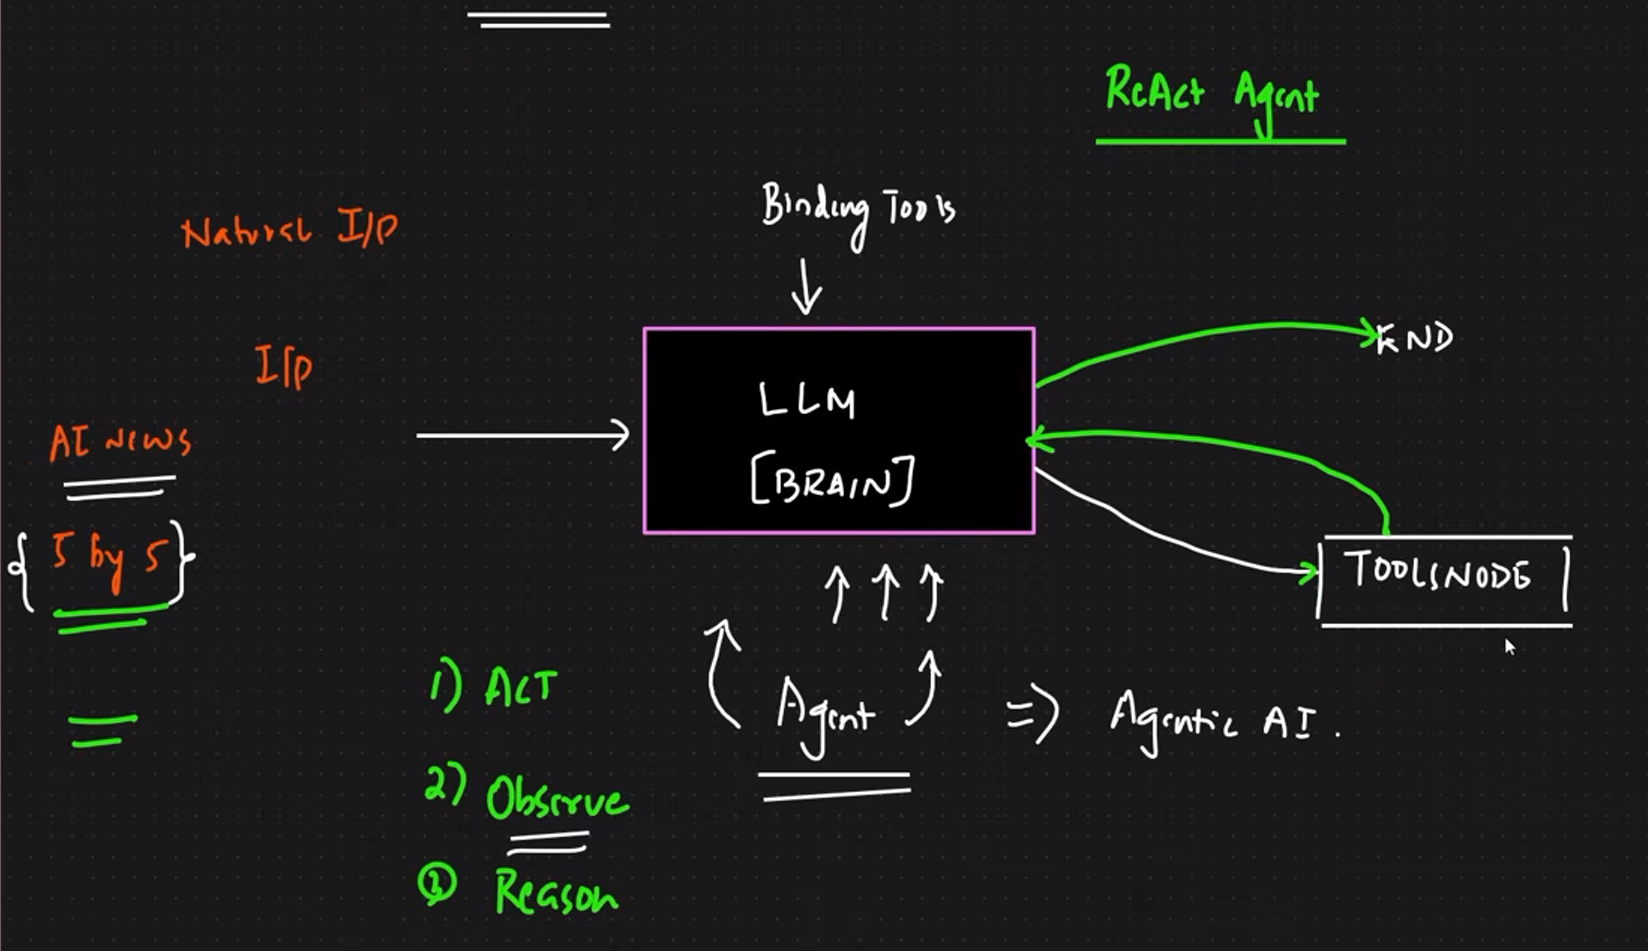

In [ ]:
## reAct Agent architecture 
# we eill use same state graoh

# reAct Agent Architecture

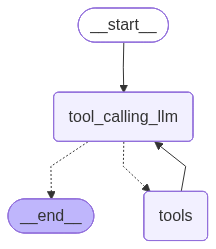

In [ ]:
# Creating a state graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node Defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# adding edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                              # if the latest message in the messages list contains a tool call, then go to the tools node
                              # if the latest message in the messages list does not contain a tool call, then go to the end node
                               tools_condition)
builder.add_edge("tools", "tool_calling_llm")      # after tool is called, go back to the llm node to see if there are more tool calls
# just keep repeatign this process until there are no more tool calls and then go to end node
## compileing the graph

graph=builder.compile()
from IPython.display import Image,  display
display(Image(graph.get_graph().draw_mermaid_png()))

In [126]:
response=graph.invoke({"messages":"give me the recent ai news and then multiply 2 and 3"}) # check message
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

give me the recent ai news and then multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (debbrqncx)
 Call ID: debbrqncx
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://aijourn.com/uk-firms-move-from-ai-experimentation-to-measurable-results-as-the-project-economy-matures/", "title": "UK firms move from AI experimentation to measurable results as the Project Economy matures - The AI Journal", "score": 0.7447496, "published_date": "Wed, 22 Apr 2026 08:35:08 GMT", "content": "LONDON, April 22, 2026 /PRNewswire/ — New research released today from Deltek, the intelligent platf

# adding memory in agentic graph

In [ ]:
response=graph.invoke({"messages":"hello my name is kartik"}) # check message
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

what is my name
================================== Ai Message ==================================

I don't have enough information to answer that.


In [130]:
response=graph.invoke({"messages":"what is my name"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

what is my name
================================== Ai Message ==================================

I don't have any information about your name. I'm a large language model, I don't have the ability to know or retain information about individual users. Each time you interact with me, it's a new conversation and I don't have any prior knowledge or context. If you'd like to tell me your name, I'd be happy to chat with you!


In [ ]:
# here its not saving And I just now told that my name is Kartik but he was not able to get my name when I ask what is my name so this is something that it is not saving

In [ ]:
# creating memery saaver check point

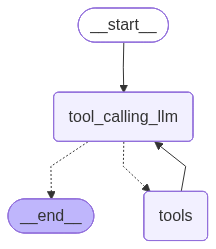

In [149]:
# Creating a state graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()


# Node Defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# adding edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                              # if the latest message in the messages list contains a tool call, then go to the tools node
                              # if the latest message in the messages list does not contain a tool call, then go to the end node
                               tools_condition)
builder.add_edge("tools", "tool_calling_llm")      # after tool is called, go back to the llm node to see if there are more tool calls
# just keep repeatign this process until there are no more tool calls and then go to end node
## compileing the graph

graph=builder.compile(checkpointer=memory)              # passing the memory checkpointer to the graph so that it can save the state of the graph in the memory checkpointer.
from IPython.display import Image,  display
display(Image(graph.get_graph().draw_mermaid_png()))

In [150]:
config={"configurable": {"thread_id":1}} # syntax 
response=graph.invoke({"messages":"hello my name is kartik"}, config=config) # check message
response

{'messages': [HumanMessage(content='hello my name is kartik', additional_kwargs={}, response_metadata={}, id='dc227e19-57e7-4dfe-93a6-73d50bab2b0d'),
  AIMessage(content="It's nice to meet you, Kartik. Is there something I can help you with?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1751, 'total_tokens': 1771, 'completion_time': 0.039226752, 'completion_tokens_details': None, 'prompt_time': 0.13748597, 'prompt_tokens_details': None, 'queue_time': 0.170031583, 'total_time': 0.176712722}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db8c1-e0a5-7940-a1c9-77be9115eedf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1751, 'output_tokens': 20, 'total_tokens': 1771})]}

In [151]:

response["messages"][-1].content

"It's nice to meet you, Kartik. Is there something I can help you with?"

In [152]:
# checking if memory save d
response=graph.invoke({"messages":"hey what is my name"}, config=config) # check message
print(response["messages"][-1].content)


Your name is Kartik.


In [153]:
response=graph.invoke({"messages":"hey do you remember my name"}, config=config) # check message
print(response["messages"][-1].content)


Your name is Kartik.


# streamimg

In [154]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [155]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

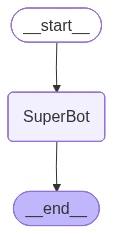

In [156]:
graph = StateGraph(State)

## node
graph.add_node("SuperBot", superbot)

## Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [157]:
config={"configurable": {"thread_id":1}} # syntax
graph_builder.invoke({"messages":"hello my name is kartik and like football"}, config=config) # check message

{'messages': [HumanMessage(content='hello my name is kartik and like football', additional_kwargs={}, response_metadata={}, id='1a234431-389a-464b-a8c7-644fab7d10c5'),
  AIMessage(content="Hello Kartik, nice to meet you. It's great to hear that you like football! Which team or league do you support? Are you a fan of the English Premier League, La Liga, or perhaps the Indian Super League?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 44, 'total_tokens': 92, 'completion_time': 0.0693399, 'completion_tokens_details': None, 'prompt_time': 0.002037747, 'prompt_tokens_details': None, 'queue_time': 0.158126325, 'total_time': 0.071377647}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db8c2-0141-7641-a79f-fceef383ba6e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'o

# Streaming

## Methods: .stream() and astream()

### These methods are sync and async methods for streaming back results.

#### Additional parameters in streaming modes for graph state

##### values: This streams the full state of the graph after each node is called.
##### updates: This streams updates to the state of the graph after each node is called.

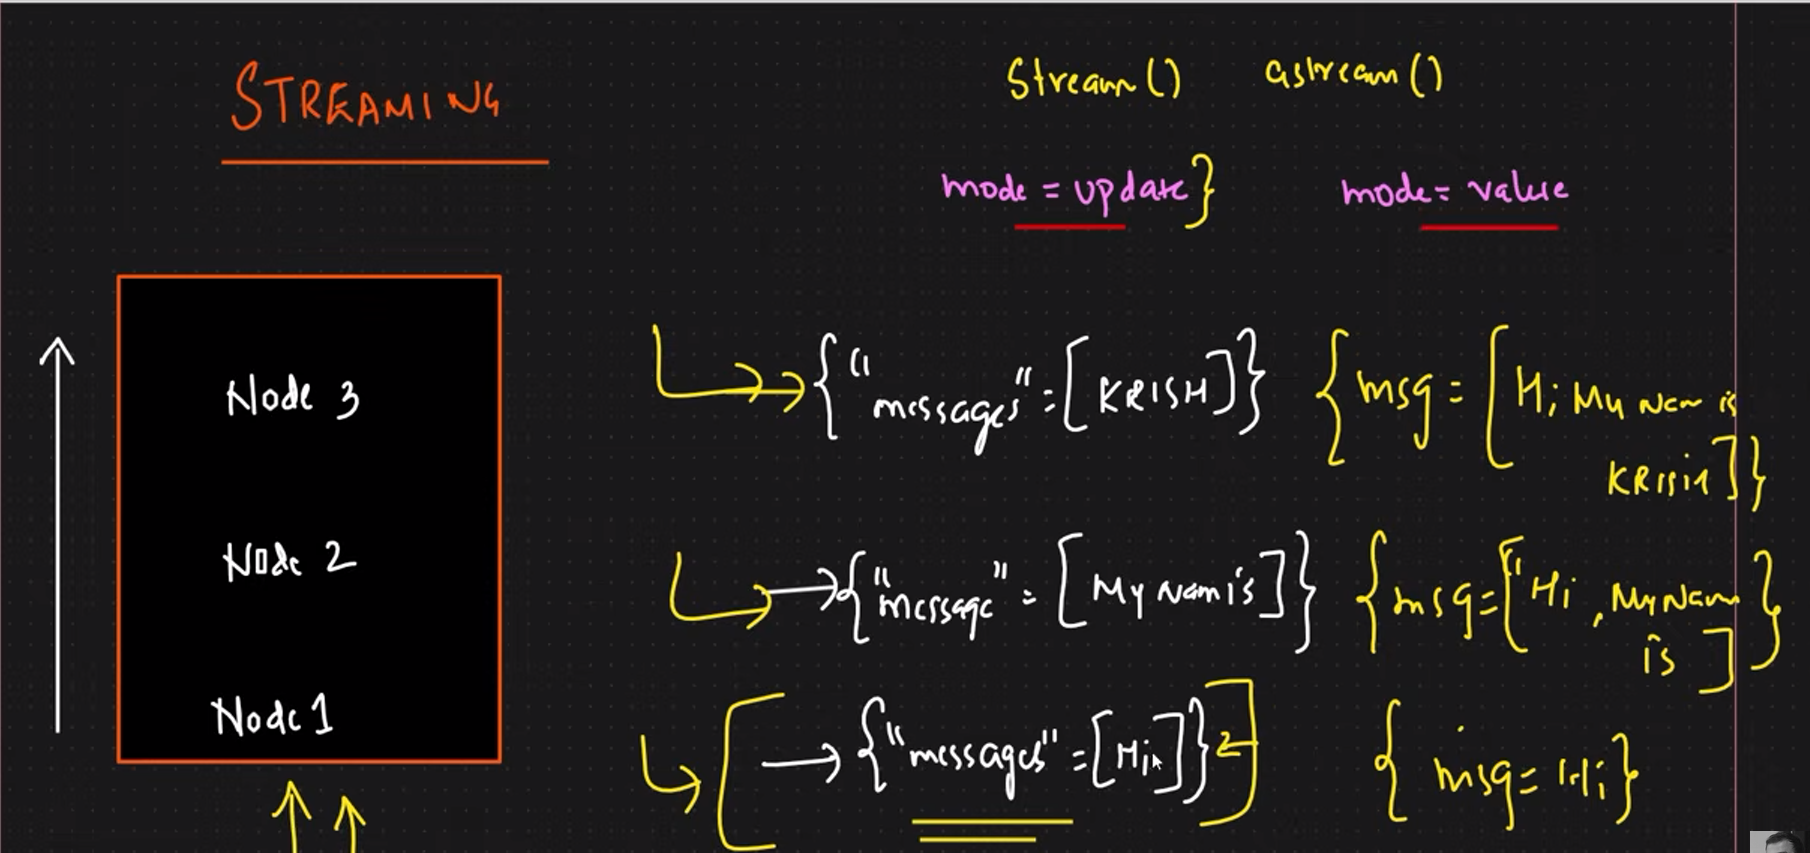

In [ ]:
config={"configurable":{"thread_id":"3"}}
for chunk in graph_builder.stream({"messages":"hello my name is kartik and like football"}, config=config, stream_mode="updates"):
    print(chunk)
# there are 2 steam modes "updates" and "values"
# here only ai message is printed because we are using "updates" mode which only gives the updated messages in the state.

{'SuperBot': {'messages': [AIMessage(content="Hello Kartik, nice to meet you. Football is a great sport, is there a particular team or league you're interested in?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 44, 'total_tokens': 72, 'completion_time': 0.051555327, 'completion_tokens_details': None, 'prompt_time': 0.002810909, 'prompt_tokens_details': None, 'queue_time': 0.05266236, 'total_time': 0.054366236}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db8c2-0ac3-71a3-9d69-5c8d79fa7b8a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 28, 'total_tokens': 72})]}}


In [ ]:

for chunk in graph_builder.stream({"messages":"hello my name is kartik and like football"}, config=config, stream_mode="values"):
    print(chunk)
    # and here in values mode the whole state is printed in each chunk so we can see the messages 
    # list getting updated with the new messages.

{'messages': [HumanMessage(content='hello my name is kartik and like football', additional_kwargs={}, response_metadata={}, id='6ba888c1-467c-4329-a6ca-a579b31903c4'), AIMessage(content="Hello Kartik, nice to meet you. Football is a great sport, is there a particular team or league you're interested in?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 44, 'total_tokens': 72, 'completion_time': 0.051555327, 'completion_tokens_details': None, 'prompt_time': 0.002810909, 'prompt_tokens_details': None, 'queue_time': 0.05266236, 'total_time': 0.054366236}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db8c2-0ac3-71a3-9d69-5c8d79fa7b8a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 28, 'total_tokens': 72}), HumanMessage(content='hello my name is karti

In [161]:
config={"configurable":{"thread_id":"4"}}
for chunk in graph_builder.stream({"messages":"hello my name is kartik and like football"}, config=config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hello Kartik. I see you mentioned you like football. Which football league or competition do you enjoy watching the most - English Premier League, La Liga, UEFA Champions League, or something else?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 97, 'total_tokens': 137, 'completion_time': 0.055430231, 'completion_tokens_details': None, 'prompt_time': 0.006235945, 'prompt_tokens_details': None, 'queue_time': 0.051683874, 'total_time': 0.061666176}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db8c4-5e25-7833-a6b4-32e8e53b0cb6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 97, 'output_tokens': 40, 'total_tokens': 137})]}}


In [162]:

for chunk in graph_builder.stream({"messages":"i also like basketball"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hello my name is kartik and like football', additional_kwargs={}, response_metadata={}, id='293d46f9-9c05-4e3f-a9b8-793d057dace4'), AIMessage(content="Nice to meet you, Kartik. Football is a great sport, isn't it? Do you have a favorite team or player that you like to watch or support?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 44, 'total_tokens': 79, 'completion_time': 0.067738526, 'completion_tokens_details': None, 'prompt_time': 0.002961083, 'prompt_tokens_details': None, 'queue_time': 0.159056375, 'total_time': 0.070699609}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db8c4-2962-7fa0-ba4a-2fb5f7d84ad4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 35, 'total_tokens': 79}), HumanMessage(content='hel

In [ ]:
config={"configurable":{"thread_id":"5"}}
async for event in graph_builder.astream_events({"messages":"hello my name is kartik and like football"}, config=config, version="v2"):
    print(event)
    # detailed 

{'event': 'on_chain_start', 'data': {'input': {'messages': 'hello my name is kartik and like football'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019db8c7-5e1e-7941-81b1-3ad18c1e59d9', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='hello my name is kartik and like football', additional_kwargs={}, response_metadata={}, id='5604ec5f-64c9-445f-87f5-246a5a554c84')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019db8c7-5e21-7123-8839-f4952696c562', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:621706ff-738e-8e02-e462-63c8323ddac9'}, 'parent_ids': ['019db8c7-5e1e-7941-81b1-3ad18c1e59d9']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMess